In [2]:
import numpy as np
import pandas as pd
import torch
import esm   
# from Bio import SeqIO
import torch
# import gc
from sklearn.manifold import TSNE
from sklearn import metrics
import matplotlib.pyplot as plt
import pickle

from sklearn.decomposition import PCA


# #for google colab only
# !pip install fair-esm


## Background info

ESM (Evolutionary Scale Modeling) is a deep learning framework developed by Facebook AI Research that leverages large-scale protein sequence data to generate high-quality embeddings for protein sequences. It uses a Transformer architecture to capture the intricate relationships between amino acids in a sequence, allowing the model to learn context-dependent representations that reflect the structural and functional properties of proteins. ESM is pre-trained on diverse protein databases, enabling it to understand evolutionary information and generalize well across different protein families. By converting protein sequences into high-dimensional embeddings, ESM facilitates various downstream tasks, such as predicting protein structure, function, and interactions.


background + finished stuf: Michael did this ESM class for the cs274 course. It was done for ATP binding site predictoin (that's why we have e2eatp files, I'll delete them later). ESM class was done for processing FASTA files, but we operate with pandas dataframes
The idea is: "uniprot_swiss raw csv" has all the sequencing information (and a little more), "protein atlass localizations csv" has all the information about the sequences of the proteins we're going to analyze
We should combine them both and then run the ESM model to get the representation (the last layer #33 of this model = representations). Representations are probably high dim tensor, so we'd need to learn to scale it down or work with it in some smart way

*Note this is inexpensive 650M params model, so it should run relatively quick, we could try other ones after we hit proof of concept

In [35]:
""""
This is the class Michael built in cs274 class, there we used FASTA files (which listed protein sequences + Uniprot)
"""

class ESM_model:
    """
    class does several things:
    load protein seqs from fasta file, compute embeddings for each protein
    pool the embeddings with mean or max (by choice)
    compute silhoutte score and plot tsne
    """

    def __init__(self):
        # initialize the model 
        self.fasta_lst = []
        self.family_df = pd.DataFrame()
        self.model, self.alphabet = esm.pretrained.esm2_t33_650M_UR50D()
        self.batch_converter = self.alphabet.get_batch_converter()
        self.model.eval()
        
        # #FOR USING GPU (if on google colab)
        # self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        # self.model = self.model.to(self.device)
        

    def load_data(self, fasta_file): 
        # takes in a fasta file and extracts the UniProt protein ID and sequence from each entry.
        # This function returns a list of tuples where the first element of each tuple 
        # is a UniProt protein id and the second element is the corresponding sequence.

        lst_output = []
        for record in SeqIO.parse(fasta_file, "fasta"):
            protein_id = (str(record.id).split('|')[1])
            lst_output.append((protein_id, record.seq))
        self.fasta_lst = lst_output
        return lst_output


    def get_vectors(self, list_tuples_protId_seq, batch_size):
        # takes in the list of tuples from load_fasta and returns a 
        # dictionary with the UniProt protein ids as the keys and their associated representation vectors from the ESM model as the values

        sequence_representations = {}

        for i in range(0, len(list_tuples_protId_seq), batch_size):
            batch = list_tuples_protId_seq[i : i + batch_size]
            labels, strs, tokens = self.batch_converter(batch)

            # #FOR USING GPU (if on google colab)
            # tokens = tokens.to(self.device)

                
            # Extract per-residue representations (on CPU)
            with torch.no_grad():
                results = self.model(tokens, repr_layers=[33], return_contacts=False) #dict_keys(['logits', 'representations', 'attentions', 'contacts'])
            
            # [batch_size, max_seq_len, 1280]
            token_representation = results["representations"][33] #exctract token representation (from a list of representations which consist only of 1 value)

            for j, (seq_id, seq) in enumerate(batch):
                seq_len = len(seq)
                #take out first and last vectors and average the representation for each amino acid
                #start from 1 and go to tokens_len - 1 to take out the first and last vectors that ESM puts in
                sequence_representations[seq_id] = token_representation[j, 1 : seq_len + 1]
       
        return sequence_representations


    def pool_representations(self, dict_protId_embedding, mean_max_param):

        # takes in your dictionary of per token vectors and a string parameter denoting the pooling regime (‘mean’ or ‘max) 
        # and outputs a dictionary with the UniProt protein ids 
        # as keys and the pooled embedding vectors (as a numpy object) as the values (dimension = [1,1280])

        updated_dict = {}

        if mean_max_param == 'mean':
            for seq_id in dict_protId_embedding:
                updated_dict[seq_id] = np.array(dict_protId_embedding[seq_id].mean(0))
        elif mean_max_param =='max':
            for seq_id in dict_protId_embedding:
                updated_dict[seq_id] = np.array(dict_protId_embedding[seq_id].max(dim=0)[0]) #.max gives [values, indices], get the max values to create a nww tensor
        else:
            raise ValueError("mean_max_param shuold be 'mean' or 'max'")

        return updated_dict


    # def calculate_silhouette_score (self, family_data_file, pooled_vectors_dict):
    #     # takes in the protein family metadata file and a pooled vector dictionary, calculates the silhouette score for each family, 
    #     # and returns a dataframe with the family name and corresponding score per row. 

    #     family_df = pd.read_csv(family_data_file)
    #     family_df["representations"] = family_df["protid"].map(pooled_vectors_dict) #combine embeddings and metadata
    #     embeddings_numpy = np.vstack(family_df["representations"]) #produce matrix array which has the same indexing as family_df

    #     lst_of_scores = []
    #     for family in family_df['family'].unique():
    #         labels = (family_df['family'] == family)
    #         score = metrics.silhouette_score(embeddings_numpy, labels)
    #         lst_of_scores.append([family, score])

    #     scores_df = pd.DataFrame(lst_of_scores)
    #     scores_df.columns = ['family', 'score']
    #     return scores_df
    

    
    def tsne_plot(self, pooled_dict, family_csv, outfile):
        # create t-SNE plot colored by family and saves it in output file 
        # we have 6 families, assign each a color
        color_dict = {
        'tyrosine_kinase': 'red',
        'agc_kinase': 'blue',
        'ste_ser_thr_kinase': 'green',
        'receptor_tyrosine_kinase': 'orange',
        'other': 'purple',
        'cmgc_kinase': 'brown'}
        
        
        family_df = pd.read_csv(family_csv)
        family_df["representations"] = family_df["protid"].map(pooled_dict)
        numpy_emb = np.vstack(family_df["representations"])
        labels = family_df["family"]

        #predict tsne low dimensional representation
        tsne = TSNE(n_components=2, random_state=42)
        tsne_rep = tsne.fit_transform(numpy_emb)

        colors = labels.map(color_dict) #points now colored

        plt.figure(figsize=(7, 6))
        plt.scatter(tsne_rep[:,0], tsne_rep[:,1], c=colors)

        # make legend
        for fam, col in color_dict.items():
            plt.scatter([], [], color=col, label=fam)
        plt.legend()
        plt.title('t sne plot')
        plt.savefig(outfile)


In [26]:
#DeepLoc train dataframe from deeploc paper, 
#contains protein id (called Uniprot), one-hot classes and sequences. Ignore partition column, it's how much sequences are similar to each other
df_deep_loc_reduced = pd.read_csv(r"processed_data/df_deep_loc_reduced.csv")
uniprot_sequence_example = df_deep_loc_reduced[['Uniprot', 'Sequence']].head()

# [(id1, seq1), (id2, seq2), ...]
uniprot_sequence_tuple_list = list(zip(uniprot_sequence_example['Uniprot'], uniprot_sequence_example['Sequence']))
uniprot_sequence_tuple_list = uniprot_sequence_tuple_list

In [37]:
df_deep_loc_reduced

,Uniprot,Kingdom,Partition,Membrane,Cytoplasm,Nucleus,Extracellular,Cell membrane,Mitochondrion,Plastid,Endoplasmic reticulum,Lysosome/Vacuole,Golgi apparatus,Peroxisome,Sequence
0,P82349,Metazoa,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATEQQGSNGPVKKSMREKAVERRNVNKEHNSNFKAGY...
1,Q7L5N1,Metazoa,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATNGTGGSSGMEVDAAVVPSVMACGVTGSVSVALHPL...
2,P63086,Metazoa,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAGPEMVRGQVFDVGPRYTNLSYIGEGAYGMVCSAYDNLNK...
3,P21708,Metazoa,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAPGGGGGEPRGTAGVVPVVPGEVEVVKGQPFDVGPRYTQL...
4,Q9NXW9,Metazoa,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAETPEVLRECGCKGIRTCLICERQRGSDPPWELPPAKTYRF...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11177,Q9SJ20,Viridiplantae,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MYVVKRDGRQETVHFDKITARLKKLSYGLSSDHCDPVLVAQKVCAG...
11178,P21524,Fungi,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MYVYKRDGRKEPVQFDKITARISRLCYGLDPKHIDAVKVTQRIISG...
11179,P36639,Metazoa,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,MYWSNQITRRLGERVQGFMSGISPQQMGEPEGSWSGKNPGTMGASR...
11180,Q08032,Fungi,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MYYGISQFSEAYNKILRNSSSHSSCQLVIFVSCLNIDALCATKMLS...


In [38]:
#getting out representations (embeddings) from the sequence

#ESM = protein language model (like LLM but there're only 20 tokens = amino acids)
model_esm = ESM_model()
# model_esm.fasta_lst = uniprot_sequence_tuple_list


In [ ]:
"""
This code was adapted and run on google colab with H100 high RAM
It takes dictionary of {id: sequence} and returns dictionary {id: (embeddings)}

I combined all small dictionaries into large dictionary named all_embeddings_dict.pkl. 

Dictionary structure: key = id, values = (mean representations, max representations)
"""

import os
import pickle
import torch


#SPECIFIED ROOT FOLDER IN GOOGLE COLAB
# path_to_root_folder = ""

output_dir = path_to_root_folder + r"/processed data/nuclear_locs"

df_deep_loc_the_rest = pd.read_csv(path_to_root_folder + "/processed data/df_deep_loc_the_rest.csv")
uniprot_sequence_example = df_deep_loc_the_rest[['Uniprot', 'Sequence']]

# # [(id1, seq1), (id2, seq2), ...]
uniprot_sequence_tuple_list = list(zip(uniprot_sequence_example['Uniprot'], uniprot_sequence_example['Sequence']))

big_batch_size = 128
small_batch_size = 1  #it was bigger, but some sequences are big



big_batch_size = 128
small_batch_size = 2

# got "out of memory" errors, so limit the max length to solve it
MAX_SEQUENCE_LENGTH = 2048

for i in range(0, len(uniprot_sequence_tuple_list), big_batch_size):
    current_big_batch_tuples = uniprot_sequence_tuple_list[i : i + big_batch_size]

    # Filter out sequences that are too long to prevent OOM
    filtered_big_batch_pairs_of_tuples = []
    for uniprot_id, seq in current_big_batch_tuples:
        if len(seq) <= MAX_SEQUENCE_LENGTH:
            filtered_big_batch_pairs_of_tuples.append((uniprot_id, seq))

    if not filtered_big_batch_pairs_of_tuples:
        print(f"all seqs were too big in batch {i} to {i + big_batch_size - 1}.")
        continue

    dict_representations = model_esm.get_vectors(filtered_big_batch_pairs_of_tuples, small_batch_size)

    # # check if dict_representations is empty (e.g., if get_vectors was modified to return empty for all filtered sequences)
    # if not dict_representations:
    #     print(f"all seqs were too big in batch {i} to {i + big_batch_size - 1}.")
    #     continue

    mean_repr = model_esm.pool_representations(dict_representations, 'mean')
    max_repr = model_esm.pool_representations(dict_representations, 'max')

    combined = {
    protein_id: (mean_repr[protein_id], max_repr[protein_id]) for protein_id in mean_repr
    }
    print(i)

    output_save_path = output_dir + "/embeddings" + str(i) + "_to_" + str(i + big_batch_size - 1) + ".pkl"
    with open(output_save_path, "wb") as f:
        pickle.dump(combined, f)

    #clean memory
    del dict_representations
    del mean_repr
    del max_repr
    del combined
    gc.collect()
    torch.cuda.empty_cache()

# Define paths
embeddings_dir = path_to_root_folder + r"/processed data/nuclear_locs"
consolidated_embeddings = {}

# Iterate through all pkl files in the directory
embedding_files = [f for f in os.listdir(embeddings_dir) if f.endswith('.pkl')]
print(f"{len(embedding_files)} files to merge.")

for embedding_filename in sorted(embedding_files):
    embedding_file_path = os.path.join(embeddings_dir, embedding_filename)
    try:
        with open(embedding_file_path, 'rb') as f:
            batch_embeddings = pickle.load(f)
            # Move tensors to CPU to save GPU memory
            for protein_id, embedding_tuple_value in batch_embeddings.items():
                  embedings_updated = []
                  for embedding_value in embedding_tuple_value:
                        embedings_updated.append(np.array(embedding_value.cpu()))
                  batch_embeddings[protein_id] = tuple(embedings_updated)
                  # print(batch_embeddings[protein_id])
            consolidated_embeddings.update(batch_embeddings)
    except Exception as e:
        print(f"error loading {embedding_filename}: {e}")


# Save the consolidated dictionary
consolidated_output_path = embeddings_dir + "/all_rest_deep_loc_embeddings_consolidated.pkl"
with open(consolidated_output_path, "wb") as f:
    pickle.dump(consolidated_embeddings, f)
print("done")



'\nThis code was adapted and run on google colab with H100 high RAM\nIt takes dictionary of {id: sequence} and returns dictionary {id: (embeddings)}\n\nI combined all small dictionaries into large dictionary named all_embeddings_dict.pkl. \n\nDictionary structure: key = id, values = (mean representations, max representations)\n'

In [40]:
"""
ESM returns a torch tensor of dim (seq_len, 1280), so this code was used in the loop above
to reduce the dimensions either to mean or max value inside the column 
final embeddings are 1280 vectors for all proteins, representing some latent features
"""

# mean_representation = model_esm.pool_representations(dict_representations, 'mean')
# max_representation = model_esm.pool_representations(dict_representations, 'max')
# mean_representation['P82349']

'\nESM returns a torch tensor of dim (seq_len, 1280), so this code was used in the loop above\nto reduce the dimensions either to mean or max value inside the column \nfinal embeddings are 1280 vectors for all proteins, representing some latent features\n'

## NEXT STEPS 
combine this consolidated embeddings with the previous dataset/dataframe (add both columns of mean and max vector representations)
split to train and test where *each class is represented evenly*
build a classifier based on our embeddings, possibly account for classes not being equal (for example cytosol and membrane are overrepresented) 

In [23]:
# Dictionary structure: key = id, values = (mean representations, max representations)

with open(r"processed_data\all embeddings\all_embeddings_consolidated.pkl", "rb") as f:
    all_embeddings_consolidated = pickle.load(f)
print(len(all_embeddings_consolidated))
all_embeddings_consolidated["P30409"] #example

11052


(tensor([-0.0935, -0.0454, -0.0289,  ..., -0.1680, -0.0044,  0.0528]),
 tensor([0.4082, 0.4222, 0.7666,  ..., 0.4274, 0.4022, 0.5262]))

In [35]:
for protein_id, embedding_tuple_value in all_embeddings_consolidated.items():
    embedings_updated = []
    for embedding_value in embedding_tuple_value:
        embedings_updated.append(np.array(embedding_value.cpu()))
    all_embeddings_consolidated[protein_id] = tuple(embedings_updated)


In [36]:
all_embeddings_consolidated_df = pd.DataFrame.from_dict(all_embeddings_consolidated, orient='index', columns=['mean_embedding_pooling', 'max_embedding_pooling']).reset_index(names = 'Uniprot')
all_embeddings_consolidated_df.head()

,Uniprot,mean_embedding_pooling,max_embedding_pooling
0,P30409,"[-0.09346582, -0.045364834, -0.028902728, 0.06...","[0.40817538, 0.42218578, 0.7665663, 0.73883635..."
1,P21926,"[-0.09347189, -0.04670599, -0.02738369, 0.0641...","[0.4109374, 0.40869734, 0.76397365, 0.72000796..."
2,Q12006,"[0.065066755, -0.013632398, 0.06311917, 0.0429...","[0.8073101, 0.5360879, 0.42871466, 0.810445, 0..."
3,Q9SYX2,"[-0.03233516, -0.099874936, -0.017507337, 0.09...","[0.5785855, 0.7030161, 0.51062685, 0.850708, 0..."
4,Q6UXH0,"[0.047841568, -0.06616899, 0.021149606, 0.0237...","[0.29589278, 0.5183618, 0.33248228, 0.34017497..."


In [37]:
df_deep_loc_w_embed = pd.merge(df_deep_loc_reduced, all_embeddings_consolidated_df)
df_deep_loc_w_embed.to_csv('processed_data/df_deep_loc_w_embed.csv', index=False)

In [38]:
df_deep_loc_w_embed = pd.read_csv('processed_data\df_deep_loc_w_embed.csv')
df_deep_loc_w_embed

,Uniprot,Kingdom,Partition,Membrane,Cytoplasm,Nucleus,Extracellular,Cell membrane,Mitochondrion,Plastid,Endoplasmic reticulum,Lysosome/Vacuole,Golgi apparatus,Peroxisome,Sequence,mean_embedding_pooling,max_embedding_pooling
0,P17790,Metazoa,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAGADVPCAVLALLVLGSLAAGGDATAGFIKSPLSQRRLTQDSVE...,[-2.54323427e-03 -3.51997539e-02 -8.77329782e-...,[ 0.5233782 0.5571582 0.5539394 0.572813...
1,Q2TAA5,Metazoa,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,MAAGERSWCLCKLLRFFYSLFFPGLIVCGTLCVCLVIVLWGIRLLL...,[ 2.78053265e-02 -1.33149505e-01 -3.38705331e-...,[0.49570698 0.384592 0.5110721 0.53992677 0...
2,Q8BK35,Metazoa,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAGGNRDGEKRGSRSQADSGFLGLRPTSVDPALRRRRRGPRNKKR...,[-1.50140030e-02 -3.13255899e-02 -4.88959774e-...,[ 0.4533998 0.35764313 0.35545692 0.380093...
3,Q9BX70,Metazoa,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAGGSGGRASCPPGVGVGPGTGGSPGPSANAAATPAPGNAAAAAA...,[-1.40885133e-02 -7.42692798e-02 1.17057515e-...,[0.4454031 0.5770119 0.52534264 0.5811449 0...
4,Q9NZM5,Metazoa,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAGGSGVGGKRSSKSDADSGFLGLRPTSVDPALRRRRRGPRNKKR...,[-8.88106786e-03 -4.39386070e-02 -4.58395667e-...,[ 0.4526445 0.3830284 0.28851202 0.403186...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11047,Q9SJ20,Viridiplantae,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MYVVKRDGRQETVHFDKITARLKKLSYGLSSDHCDPVLVAQKVCAG...,[ 6.24178816e-03 -7.22857490e-02 2.39542145e-...,[ 0.42116958 0.49098858 0.5553107 0.774610...
11048,P21524,Fungi,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MYVYKRDGRKEPVQFDKITARISRLCYGLDPKHIDAVKVTQRIISG...,[ 2.27677147e-03 -5.33746667e-02 8.85895267e-...,[ 0.48719904 0.5134808 0.47069153 0.629135...
11049,P36639,Metazoa,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,MYWSNQITRRLGERVQGFMSGISPQQMGEPEGSWSGKNPGTMGASR...,[-1.15942080e-02 -1.32215872e-01 -3.45480964e-...,[0.49154705 0.26188937 0.32983163 0.47162217 0...
11050,Q08032,Fungi,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MYYGISQFSEAYNKILRNSSSHSSCQLVIFVSCLNIDALCATKMLS...,[ 1.35339210e-02 -4.68714396e-03 9.81702283e-...,[ 0.35402212 0.4029465 0.474637 0.509649...


In [40]:
mean_embedding_pooling_array = np.vstack(df_deep_loc_w_embed['mean_embedding_pooling'])
# max_embedding_pooling_array  = np.vstack(df_deep_loc_w_embed['max_embedding_pooling'])
mean_embedding_pooling_array

KeyboardInterrupt: 

In [ ]:
locations = ['Membrane', 'Cytoplasm', 'Nucleus', 'Extracellular', 'Cell membrane',
             'Mitochondrion', 'Plastid', 'Endoplasmic reticulum', 'Lysosome/Vacuole',
             'Golgi apparatus', 'Peroxisome']

# Merge to align embeddings with labels (both have ~11k rows but potentially different order)
merged_df = pd.merge(df_deep_loc_reduced, all_embeddings_consolidated_df, on='Uniprot')
mean_embedding_pooling_array = np.vstack(merged_df['mean_embedding_pooling'])
max_embedding_pooling_array  = np.vstack(merged_df['max_embedding_pooling'])
labels_df = merged_df[locations]

# 11 distinct colors via tab20
_cmap = plt.cm.get_cmap('tab20', 11)
location_colors = {loc: _cmap(i) for i, loc in enumerate(locations)}

# # 

C:\Users\micha\AppData\Local\Temp\ipykernel_35064\718922196.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cmap = plt.cm.get_cmap('tab20', 11)


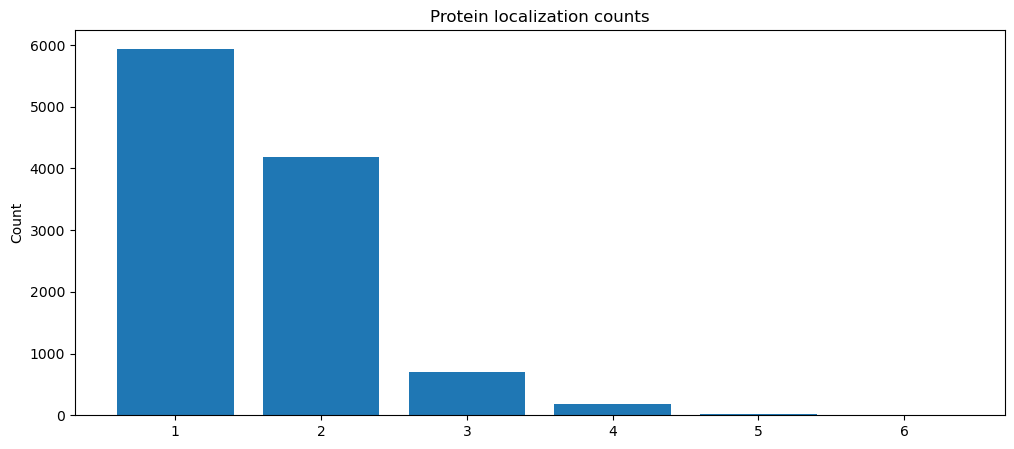

In [45]:
def count_labels(labels_df):
    count = []
    for _, row in labels_df.iterrows():
        active = [loc for loc in locations if row[loc] == 1.0]
        count.append(len(active))
    return count

count_how_many_repeated_labels = count_labels(labels_df)

plt.figure(figsize=(12, 5))
plt.bar(*np.unique(count_how_many_repeated_labels, return_counts=True))
plt.ylabel('Count')
plt.title('Protein localization counts')
plt.show()


In [46]:
np.unique(count_how_many_repeated_labels, return_counts=True)

(array([1, 2, 3, 4, 5, 6]),
 array([5942, 4193,  707,  178,   27,    5], dtype=int64))

KeyboardInterrupt: 

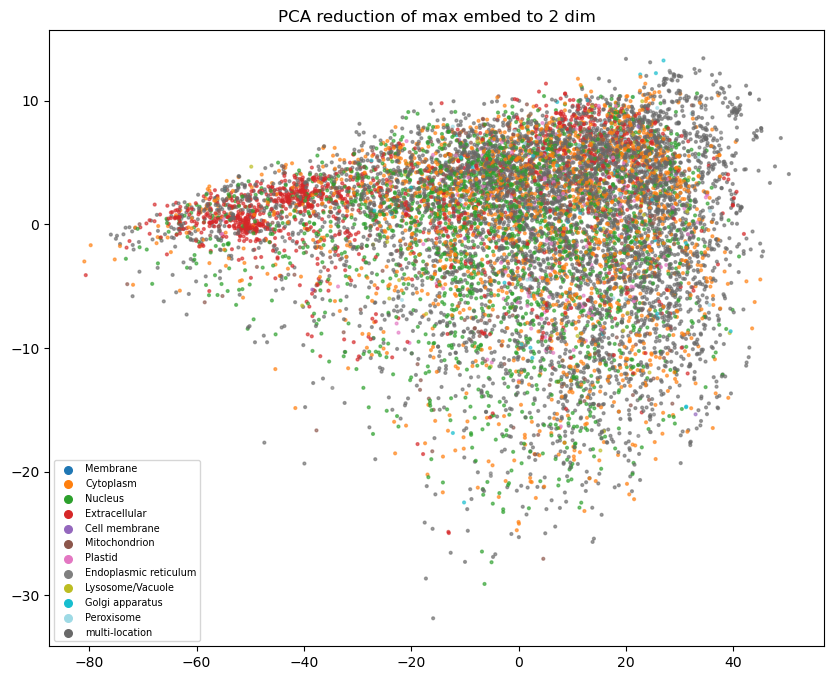

In [47]:
plot_PCA_and_tSNE(max_embedding_pooling_array, labels_df, 'max')

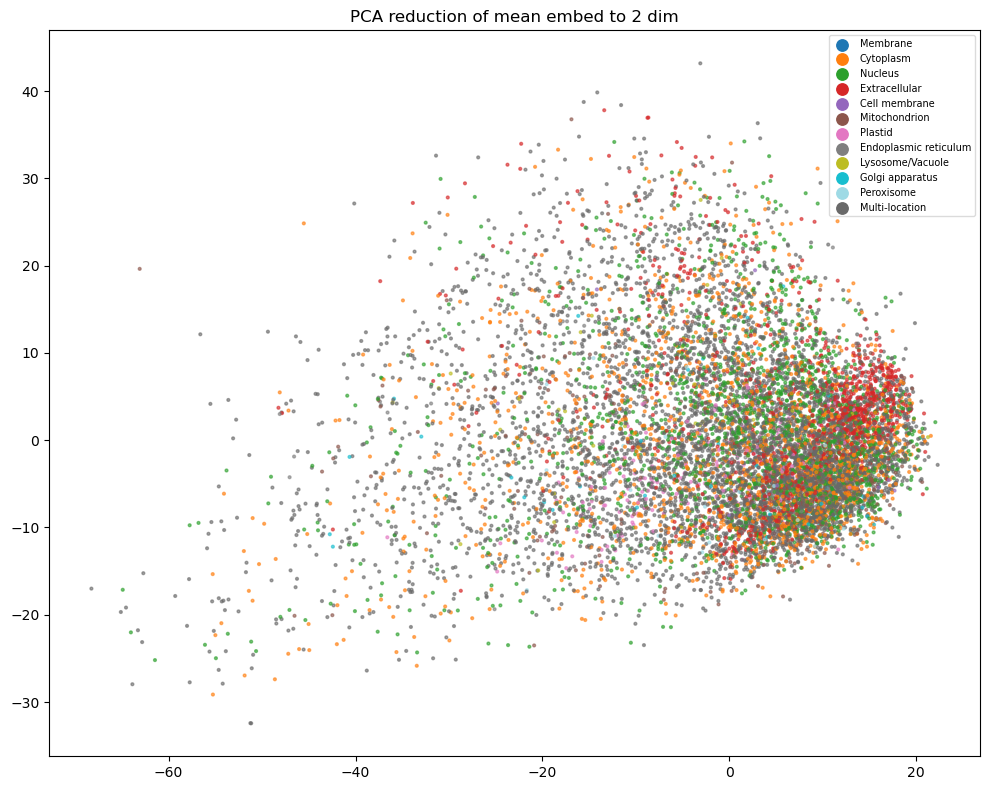

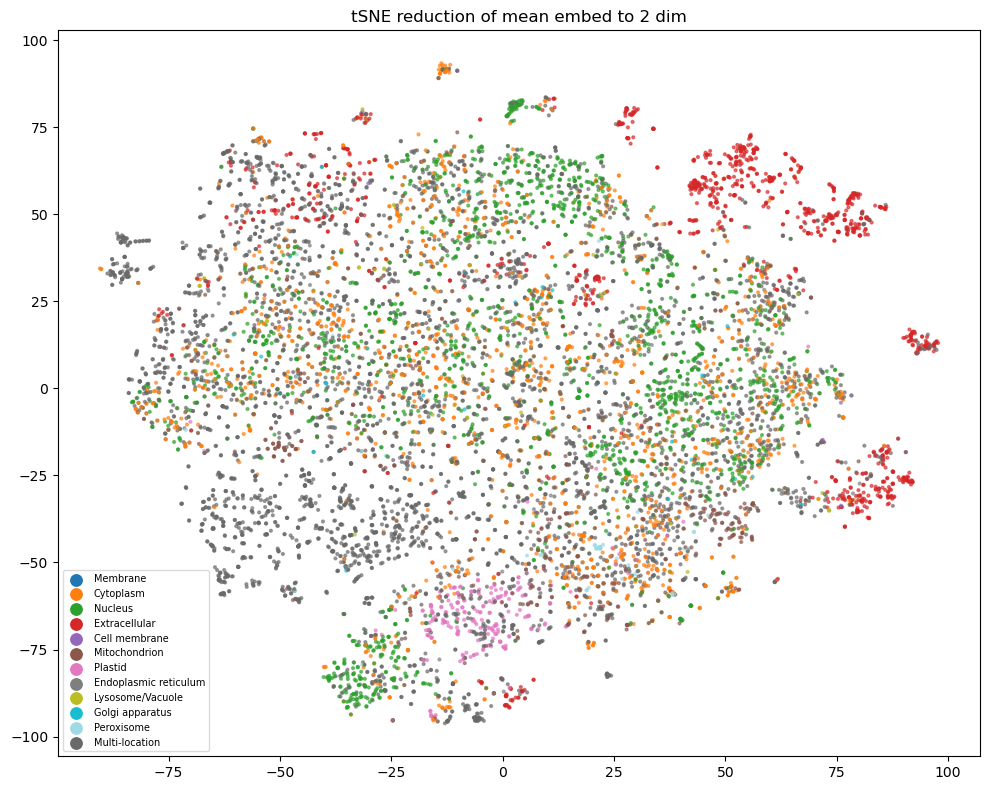

In [ ]:
plot_PCA_and_tSNE(mean_embedding_pooling_array, labels_df, 'mean')

In [ ]:
with open(r"processed_data\all embeddings\test_set_embeddings_consolidated.pkl", "rb") as f:
    test_embed_consolidated = pickle.load(f)
print(len(test_embed_consolidated)) 

1716


In [ ]:
test_deep_loc_df = pd.read_csv("raw data/hpa_testset.csv")
test_embed_consolidated_df = pd.DataFrame.from_dict(test_embed_consolidated, orient='index', columns=['mean_embedding_pooling', 'max_embedding_pooling']).reset_index(names = 'sid')
test_embed_consolidated_df.head()

,sid,mean_embedding_pooling,max_embedding_pooling
0,ENSP00000355743,"[tensor(0.0112), tensor(-0.0048), tensor(0.000...","[tensor(0.4739), tensor(0.5837), tensor(0.5041..."
1,ENSP00000429628,"[tensor(0.0378), tensor(0.0553), tensor(0.0619...","[tensor(0.3148), tensor(0.4365), tensor(0.3135..."
2,ENSP00000266544,"[tensor(0.0047), tensor(0.0246), tensor(-0.014...","[tensor(0.6990), tensor(0.5342), tensor(0.5687..."
3,ENSP00000470652,"[tensor(-0.1027), tensor(-0.0856), tensor(-0.0...","[tensor(0.3551), tensor(0.7333), tensor(0.6637..."
4,ENSP00000460751,"[tensor(0.0241), tensor(0.0975), tensor(0.0069...","[tensor(0.3857), tensor(0.4476), tensor(0.3655..."


In [56]:
df_test_deep_loc_w_embed = pd.merge(test_deep_loc_df, test_embed_consolidated_df)
df_test_deep_loc_w_embed

,sid,Cell membrane,Cytoplasm,Endoplasmic reticulum,Golgi apparatus,Lysosome/Vacuole,Mitochondrion,Nucleus,Peroxisome,Lengths,fasta,mean_embedding_pooling,max_embedding_pooling
0,ENSP00000355743,0,0,0,0,0,0,1,0,496,MAAAAGPGAALSPRPCDSDPATPGAQSPKDDNEDNSNDGTQPSKRR...,"[tensor(0.0112), tensor(-0.0048), tensor(0.000...","[tensor(0.4739), tensor(0.5837), tensor(0.5041..."
1,ENSP00000429628,0,0,0,0,0,0,1,0,173,MAAAALRDPAQVPVAADLLTDHEEGYVTFEDVAVYFSQEEWRLLDD...,"[tensor(0.0378), tensor(0.0553), tensor(0.0619...","[tensor(0.3148), tensor(0.4365), tensor(0.3135..."
2,ENSP00000266544,0,0,0,0,0,1,0,0,377,MAAAAQSRVVRVLSMSRSAITAIATSVCHGPPCRQLHHALMPHGKG...,"[tensor(0.0047), tensor(0.0246), tensor(-0.014...","[tensor(0.6990), tensor(0.5342), tensor(0.5687..."
3,ENSP00000470652,0,0,0,1,0,0,0,0,410,MAAAAVGAGHGAGGPGAASSSGGAREGARVAALCLLWYALSAGGNV...,"[tensor(-0.1027), tensor(-0.0856), tensor(-0.0...","[tensor(0.3551), tensor(0.7333), tensor(0.6637..."
4,ENSP00000460751,0,0,0,0,0,0,1,0,163,MAAAAVTRGTPGENSHHLKIFLPKKLLECLPRCPLLPPERLRWNTN...,"[tensor(0.0241), tensor(0.0975), tensor(0.0069...","[tensor(0.3857), tensor(0.4476), tensor(0.3655..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1711,ENSP00000379284,0,0,0,0,0,1,0,0,372,MYSCFSHREGEDWQRVRSAFQKKLMKPGEVMKLDNKINEVLADFMG...,"[tensor(0.0356), tensor(-0.0615), tensor(-0.03...","[tensor(0.4548), tensor(0.4106), tensor(0.4518..."
1712,ENSP00000430164,0,1,0,0,0,0,0,0,73,MYSGAGPGKSWNTWSSTLKHRSLGIGSPCLTAGRIYTQPCPFRLGG...,"[tensor(0.1415), tensor(-0.0784), tensor(0.095...","[tensor(0.2487), tensor(0.1554), tensor(0.2624..."
1713,ENSP00000414655,0,1,0,0,0,0,0,0,174,MYSPIIYQALCEHVQTQMSLMNDLTSKNIPNGIPAVPCHAPSHSES...,"[tensor(0.0505), tensor(-0.0638), tensor(0.043...","[tensor(0.2805), tensor(0.2278), tensor(0.2461..."
1714,ENSP00000392070,0,0,0,0,0,0,1,0,327,MYYAREPGKINHMRYDTLAQMLTLGNIRAGNKMIVMETCAGLVLGA...,"[tensor(0.0346), tensor(-0.0603), tensor(0.008...","[tensor(0.4391), tensor(0.5006), tensor(0.4969..."


In [ ]:
test_mean_array = np.vstack(df_test_deep_loc_w_embed['mean_embedding_pooling'])
test_max_array  = np.vstack(df_test_deep_loc_w_embed['max_embedding_pooling'])

test_meta_cols = [c for c in df_test_deep_loc_w_embed.columns
                  if c not in ('mean_embedding_pooling', 'max_embedding_pooling')]
test_emb_cols = [f'emb_{i}' for i in range(test_mean_array.shape[1])]

df_test_loc_mean = pd.concat(
    [df_test_deep_loc_w_embed[test_meta_cols].reset_index(drop=True),
     pd.DataFrame(test_mean_array, columns=test_emb_cols)],
    axis=1
)

df_test_loc_max = pd.concat(
    [df_test_deep_loc_w_embed[test_meta_cols].reset_index(drop=True),
     pd.DataFrame(test_max_array, columns=test_emb_cols)],
    axis=1
)

print(df_test_loc_mean.shape, df_test_loc_max.shape)
df_test_loc_mean.head()

(1716, 1291) (1716, 1291)


,sid,Cell membrane,Cytoplasm,Endoplasmic reticulum,Golgi apparatus,Lysosome/Vacuole,Mitochondrion,Nucleus,Peroxisome,Lengths,...,emb_1270,emb_1271,emb_1272,emb_1273,emb_1274,emb_1275,emb_1276,emb_1277,emb_1278,emb_1279
0,ENSP00000355743,0,0,0,0,0,0,1,0,496,...,0.031718,-0.013373,-0.086283,0.021941,0.043731,-0.038634,-0.012945,-0.079487,0.026372,0.072548
1,ENSP00000429628,0,0,0,0,0,0,1,0,173,...,0.001135,0.030932,-0.146183,0.066755,0.002842,0.079113,-0.032848,0.112453,-0.019420,-0.031711
2,ENSP00000266544,0,0,0,0,0,1,0,0,377,...,-0.028935,-0.068377,-0.122130,0.030627,-0.011897,0.133742,0.118325,-0.128093,-0.018213,0.068064
3,ENSP00000470652,0,0,0,1,0,0,0,0,410,...,-0.110978,-0.017669,-0.153179,0.136735,-0.047234,-0.049449,-0.069719,-0.165774,0.040182,0.082597
4,ENSP00000460751,0,0,0,0,0,0,1,0,163,...,0.061244,-0.033396,-0.173113,0.105947,-0.024250,-0.010444,-0.023889,-0.135920,-0.074510,0.065971


In [60]:
df_test_loc_mean.to_csv('processed_data/df_test_loc_mean.csv', index=False)
df_test_loc_max.to_csv('processed_data/df_test_loc_max.csv', index=False)

In [58]:
meta_cols = ['Uniprot', 'Kingdom', 'Partition'] + locations

emb_cols = [f'emb_{i}' for i in range(mean_embedding_pooling_array.shape[1])]

df_loc_mean = pd.concat(
    [merged_df[meta_cols].reset_index(drop=True),
     pd.DataFrame(mean_embedding_pooling_array, columns=emb_cols)],
    axis=1
)

df_loc_max = pd.concat(
    [merged_df[meta_cols].reset_index(drop=True),
     pd.DataFrame(max_embedding_pooling_array, columns=emb_cols)],
    axis=1
)

print(df_loc_mean.shape, df_loc_max.shape)
df_loc_mean.head()

(11052, 1294) (11052, 1294)


,Uniprot,Kingdom,Partition,Membrane,Cytoplasm,Nucleus,Extracellular,Cell membrane,Mitochondrion,Plastid,...,emb_1270,emb_1271,emb_1272,emb_1273,emb_1274,emb_1275,emb_1276,emb_1277,emb_1278,emb_1279
0,P17790,Metazoa,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.027346,-0.088689,-0.122844,0.017037,0.035853,-0.146838,0.016916,-0.209896,0.026933,0.126046
1,Q2TAA5,Metazoa,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.045660,-0.007070,-0.091518,0.004498,-0.030185,-0.012738,0.058058,-0.108965,-0.022603,0.059764
2,Q8BK35,Metazoa,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.080223,-0.014417,-0.161001,0.002992,0.075531,-0.137908,0.004606,0.036928,0.103632,0.016602
3,Q9BX70,Metazoa,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.008914,-0.044490,-0.103282,0.078096,-0.045097,-0.098371,0.018084,-0.139828,0.029559,0.195377
4,Q9NZM5,Metazoa,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.107922,-0.007846,-0.195480,0.016586,0.061735,-0.166234,-0.006503,0.034651,0.112688,0.020742


In [61]:
df_loc_mean.to_csv('processed_data/df_train_loc_mean.csv', index=False)
df_loc_max.to_csv('processed_data/df_train_loc_max.csv', index=False)